In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv('../data/gaia_cleaned.csv')

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

print("Scaling done!")

Scaling done!


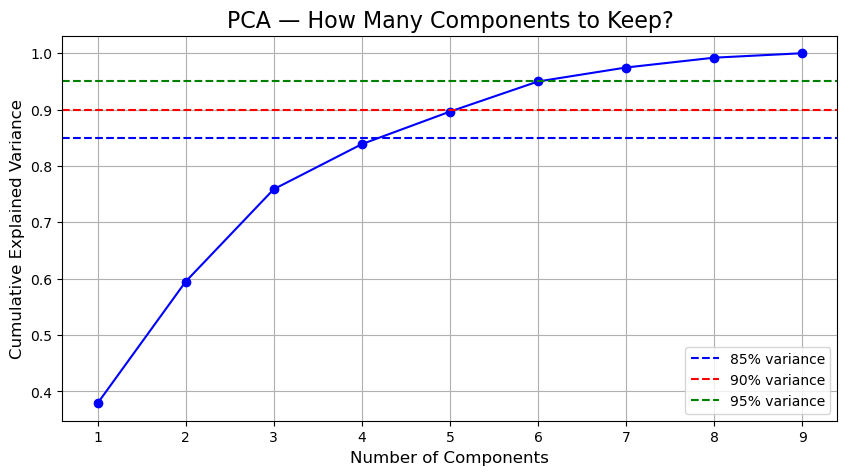


Variance explained by each component:
PC1: 0.3792 (37.92%)
PC2: 0.2158 (21.58%)
PC3: 0.1639 (16.39%)
PC4: 0.0799 (7.99%)
PC5: 0.0577 (5.77%)
PC6: 0.0534 (5.34%)
PC7: 0.0248 (2.48%)
PC8: 0.0174 (1.74%)
PC9: 0.0079 (0.79%)


In [2]:
pca_full = PCA()
pca_full.fit(df_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 10), cumulative_variance, 'bo-')
plt.axhline(y=0.85, color='b', linestyle='--', label='85% variance')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% variance')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% variance')
plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance', fontsize=12)
plt.title('PCA — How Many Components to Keep?', fontsize=16)
plt.legend()
plt.grid(True)
plt.savefig('../images/pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nVariance explained by each component:")
for i, var in enumerate(explained_variance):
    print(f"PC{i+1}: {var:.4f} ({var*100:.2f}%)")

In [3]:
pca = PCA(n_components=4)
df_pca = pca.fit_transform(df_scaled)

print("PCA Shape:", df_pca.shape)
print("Variance retained:", sum(pca.explained_variance_ratio_)*100, "%")

df_pca = pd.DataFrame(df_pca, columns=['PC1', 'PC2', 'PC3', 'PC4'])
df_pca.to_csv('../data/gaia_pca.csv', index=False)
print("PCA data saved for clustering! (4 components)")

pca_viz = PCA(n_components=3)
df_pca_viz = pca_viz.fit_transform(df_scaled)

df_pca_viz = pd.DataFrame(df_pca_viz, columns=['PC1', 'PC2', 'PC3'])
print("PCA data saved for Visualization! (3 components)")

PCA Shape: (50000, 4)
Variance retained: 83.87258573960177 %
PCA data saved for clustering! (4 components)
PCA data saved for Visualization! (3 components)


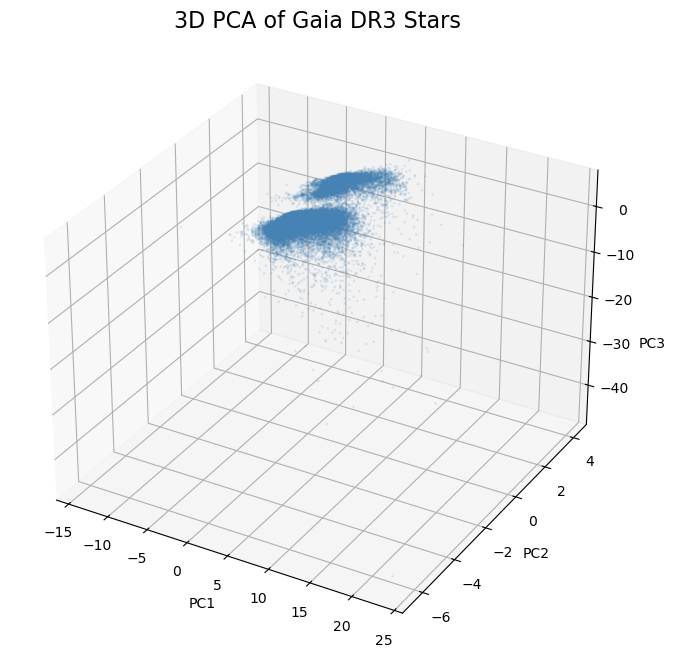

In [4]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(df_pca_viz['PC1'], df_pca_viz['PC2'], df_pca_viz['PC3'],
                     alpha=0.1, s=1,
                     color='steelblue')

ax.set_xlabel('PC1', fontsize=10)
ax.set_ylabel('PC2', fontsize=10)
ax.set_zlabel('')

ax.text2D(1.02, 0.5, 'PC3', transform=ax.transAxes, fontsize=10, va='center')

ax.set_title('3D PCA of Gaia DR3 Stars', fontsize=16)
plt.savefig('../images/pca_3d.png', dpi=150)
plt.show()